In [280]:
import pandas as pd          # for data handling
import numpy as np           # for numerical operations
import matplotlib.pyplot as plt   # for graphs
import seaborn as sns

from sklearn.model_selection import train_test_split   # split data
from sklearn.ensemble import RandomForestRegressor     # ML model
from sklearn.metrics import mean_absolute_error        # evaluation
from sklearn.metrics import r2_score

In [281]:
df = pd.read_excel("election_dataset.xlsx",header=1)

df.columns = df.columns.str.strip().str.lower()

# only object columns (faster & cleaner)
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.lower().str.strip()

In [282]:
df.shape

(46, 22)

In [284]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46 entries, 0 to 45
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   resp_id             46 non-null     int64  
 1   district            45 non-null     object 
 2   constituency        45 non-null     object 
 3   region              45 non-null     object 
 4   seats               45 non-null     float64
 5   voter_turnout_2021  45 non-null     float64
 6   nda_vote_pct        44 non-null     float64
 7   spa_vote_pct        2 non-null      object 
 8   tvk_vote_pct        44 non-null     float64
 9   ntk_vote_pct        44 non-null     float64
 10  others_pct          42 non-null     float64
 11  anti_incumbency     45 non-null     float64
 12  tvk_youth_index     45 non-null     object 
 13  urban_rural         45 non-null     object 
 14  respondents         43 non-null     float64
 15  survey_agency       45 non-null     object 
 16  survey_dat

In [285]:
print(df.columns.tolist())

['resp_id', 'district', 'constituency', 'region', 'seats', 'voter_turnout_2021', 'nda_vote_pct', 'spa_vote_pct', 'tvk_vote_pct', 'ntk_vote_pct', 'others_pct', 'anti_incumbency', 'tvk_youth_index', 'urban_rural', 'respondents', 'survey_agency', 'survey_date', 'nda_2021_seats', 'spa_2021_seats', 'caste_dominant', 'swing_voter_pct', 'notes']


In [286]:
print(df.isnull().sum())

resp_id                0
district               1
constituency           1
region                 1
seats                  1
voter_turnout_2021     1
nda_vote_pct           2
spa_vote_pct          44
tvk_vote_pct           2
ntk_vote_pct           2
others_pct             4
anti_incumbency        1
tvk_youth_index        1
urban_rural            1
respondents            3
survey_agency          1
survey_date            1
nda_2021_seats         1
spa_2021_seats         1
caste_dominant         1
swing_voter_pct        2
notes                 29
dtype: int64


In [287]:
num_cols = df.select_dtypes(include=np.number).columns

df[num_cols] = df[num_cols].fillna(df[num_cols].median())
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])
df['tvk_youth_index'] = df['tvk_youth_index'].fillna(2)

In [288]:
df.head(44)

,resp_id,district,constituency,region,seats,voter_turnout_2021,nda_vote_pct,spa_vote_pct,tvk_vote_pct,ntk_vote_pct,...,tvk_youth_index,urban_rural,respondents,survey_agency,survey_date,nda_2021_seats,spa_2021_seats,caste_dominant,swing_voter_pct,notes
0,1,chennai,thousands lights,north urban,6.0,66.2,38.50,35.9%,14.2,4.8,...,high,urban,31450.0,ians-matrize,mar-2026,1.0,5.0,bc/fc mix,11.2,spa stronghold; tvk urban surge
1,2,chennai,t.nagar,north urban,4.0,64.5,37.20,35.9%,13.8,4.9,...,high,urban,28000.0,parawheel,feb-2026,1.0,3.0,bc/fc mix,10.5,% symbol error; anti_inc as string
2,3,chennai,saidapet,north urban,4.0,65.1,36.90,42.1%,14.5,4.7,...,high,urban,5800.0,ians-matrize,mar-2026,0.0,4.0,bc mix,11.8,missing others% — data entry error
3,4,chennai,harbour,north urban,4.0,63.8,39.10,35.9%,13.2,5.1,...,high,urban,29500.0,parawheel,feb-2026,1.0,3.0,sc/bc,10.1,casing error in district
4,5,tiruvallur,tiruvallur,north rural,5.0,69.4,40.20,35.9%,13.0,6.2,...,mid,semi-urban,7200.0,poll matrix,jan-2026,2.0,3.0,vanniar,9.8,% symbol error; anti_inc as string
5,6,chengalpattu,chengalpattu,south chennai belt,4.0,70.1,41.00,35.9%,12.8,6.0,...,mid,semi-urban,6800.0,ians-matrize,mar-2026,2.0,2.0,bc/mbc,9.5,% symbol error; anti_inc as string
6,7,kancheepuram,kancheepuram,south chennai belt,4.0,71.2,40.50,35.9%,13.1,5.9,...,mid,semi-urban,7100.0,parawheel,feb-2026,1.0,3.0,vellalar,9.2,% symbol error; anti_inc as string
7,8,vellore,vellore,vanniar belt,5.0,72.3,42.10,35.9%,12.4,7.2,...,mid,semi-urban,6500.0,poll matrix,jan 2026,2.0,3.0,vanniar,8.9,date format error
8,9,ranipet,arcot,vanniar belt,3.0,71.8,41.80,35.9%,12.6,7.0,...,mid,rural,5200.0,ians-matrize,mar-2026,1.0,2.0,vanniar,9.1,% symbol error; anti_inc as string
9,10,tirupattur,tirupattur,vanniar belt,3.0,70.5,42.50,35.9%,12.2,7.1,...,mid,rural,4800.0,parawheel,mar-2026,1.0,2.0,vanniar,8.7,% symbol error; anti_inc as string


In [289]:
df = df[df['swing_voter_pct'] != 0]
df['spa_vote_pct'] = pd.to_numeric(df['spa_vote_pct'].str.replace('%','', regex=False), errors='coerce')

In [290]:
print(df.isnull().sum())

resp_id               0
district              0
constituency          0
region                0
seats                 0
voter_turnout_2021    0
nda_vote_pct          0
spa_vote_pct          0
tvk_vote_pct          0
ntk_vote_pct          0
others_pct            0
anti_incumbency       0
tvk_youth_index       0
urban_rural           0
respondents           0
survey_agency         0
survey_date           0
nda_2021_seats        0
spa_2021_seats        0
caste_dominant        0
swing_voter_pct       0
notes                 0
dtype: int64


In [291]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46 entries, 0 to 45
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   resp_id             46 non-null     int64  
 1   district            46 non-null     object 
 2   constituency        46 non-null     object 
 3   region              46 non-null     object 
 4   seats               46 non-null     float64
 5   voter_turnout_2021  46 non-null     float64
 6   nda_vote_pct        46 non-null     float64
 7   spa_vote_pct        46 non-null     float64
 8   tvk_vote_pct        46 non-null     float64
 9   ntk_vote_pct        46 non-null     float64
 10  others_pct          46 non-null     float64
 11  anti_incumbency     46 non-null     float64
 12  tvk_youth_index     46 non-null     object 
 13  urban_rural         46 non-null     object 
 14  respondents         46 non-null     float64
 15  survey_agency       46 non-null     object 
 16  survey_dat

In [292]:
df['survey_date'] = pd.to_datetime(df['survey_date'], errors='coerce')

C:\Users\Dell\AppData\Local\Temp\ipykernel_13240\4155889721.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['survey_date'] = pd.to_datetime(df['survey_date'], errors='coerce')


In [293]:
print(df.columns.tolist())

['resp_id', 'district', 'constituency', 'region', 'seats', 'voter_turnout_2021', 'nda_vote_pct', 'spa_vote_pct', 'tvk_vote_pct', 'ntk_vote_pct', 'others_pct', 'anti_incumbency', 'tvk_youth_index', 'urban_rural', 'respondents', 'survey_agency', 'survey_date', 'nda_2021_seats', 'spa_2021_seats', 'caste_dominant', 'swing_voter_pct', 'notes']


In [294]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46 entries, 0 to 45
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   resp_id             46 non-null     int64         
 1   district            46 non-null     object        
 2   constituency        46 non-null     object        
 3   region              46 non-null     object        
 4   seats               46 non-null     float64       
 5   voter_turnout_2021  46 non-null     float64       
 6   nda_vote_pct        46 non-null     float64       
 7   spa_vote_pct        46 non-null     float64       
 8   tvk_vote_pct        46 non-null     float64       
 9   ntk_vote_pct        46 non-null     float64       
 10  others_pct          46 non-null     float64       
 11  anti_incumbency     46 non-null     float64       
 12  tvk_youth_index     46 non-null     object        
 13  urban_rural         46 non-null     object        
 

In [295]:
df.head(44)
df['year'] = df['survey_date'].dt.year
df['month'] = df['survey_date'].dt.month

In [296]:
df['tvk_youth_index'].unique()

array(['high', 'mid', 'low'], dtype=object)

In [297]:
df.isnull().sum()

resp_id               0
district              0
constituency          0
region                0
seats                 0
voter_turnout_2021    0
nda_vote_pct          0
spa_vote_pct          0
tvk_vote_pct          0
ntk_vote_pct          0
others_pct            0
anti_incumbency       0
tvk_youth_index       0
urban_rural           0
respondents           0
survey_agency         0
survey_date           0
nda_2021_seats        0
spa_2021_seats        0
caste_dominant        0
swing_voter_pct       0
notes                 0
year                  0
month                 0
dtype: int64

In [298]:
cols_to_drop = [
    'resp_id',
    'district',
    'region',
    'survey_agency',
    'caste_dominant',
    'urban_rural',
    'nda_2021_seats',
    'spa_2021_seats'
]
df = df.drop(cols_to_drop, axis=1,errors='ignore')

In [299]:
print(df.columns.tolist())


['constituency', 'seats', 'voter_turnout_2021', 'nda_vote_pct', 'spa_vote_pct', 'tvk_vote_pct', 'ntk_vote_pct', 'others_pct', 'anti_incumbency', 'tvk_youth_index', 'respondents', 'survey_date', 'swing_voter_pct', 'notes', 'year', 'month']


In [300]:
print(X.dtypes)

voter_turnout_2021    float64
nda_vote_pct          float64
spa_vote_pct          float64
tvk_vote_pct          float64
ntk_vote_pct          float64
others_pct            float64
anti_incumbency       float64
tvk_youth_index         int64
respondents           float64
swing_voter_pct       float64
dtype: object


In [337]:
df.head(44) 

,constituency,seats,voter_turnout_2021,nda_vote_pct,spa_vote_pct,tvk_vote_pct,ntk_vote_pct,others_pct,anti_incumbency,tvk_youth_index,respondents,survey_date,swing_voter_pct,notes,year,month,predicted_winner
0,thousands lights,6.0,66.2,38.50,35.9,14.2,4.8,2.4,6.0,3,31450.0,2026-03-01,11.2,spa stronghold; tvk urban surge,2026,3,NDA
1,t.nagar,4.0,64.5,37.20,35.9,13.8,4.9,2.6,5.0,3,28000.0,2026-02-01,10.5,% symbol error; anti_inc as string,2026,2,NDA
2,saidapet,4.0,65.1,36.90,42.1,14.5,4.7,2.5,5.0,3,5800.0,2026-03-01,11.8,missing others% — data entry error,2026,3,SPA
3,harbour,4.0,63.8,39.10,35.9,13.2,5.1,2.8,7.0,3,29500.0,2026-02-01,10.1,casing error in district,2026,2,NDA
4,tiruvallur,5.0,69.4,40.20,35.9,13.0,6.2,2.5,5.0,2,7200.0,2026-01-01,9.8,% symbol error; anti_inc as string,2026,1,NDA
5,chengalpattu,4.0,70.1,41.00,35.9,12.8,6.0,2.7,6.0,2,6800.0,2026-03-01,9.5,% symbol error; anti_inc as string,2026,3,NDA
6,kancheepuram,4.0,71.2,40.50,35.9,13.1,5.9,2.7,5.0,2,7100.0,2026-02-01,9.2,% symbol error; anti_inc as string,2026,2,NDA
7,vellore,5.0,72.3,42.10,35.9,12.4,7.2,2.1,6.0,2,6500.0,2026-01-01,8.9,date format error,2026,1,NDA
8,arcot,3.0,71.8,41.80,35.9,12.6,7.0,2.1,5.0,2,5200.0,2026-03-01,9.1,% symbol error; anti_inc as string,2026,3,NDA
9,tirupattur,3.0,70.5,42.50,35.9,12.2,7.1,2.5,5.0,2,4800.0,2026-03-01,8.7,% symbol error; anti_inc as string,2026,3,NDA


In [302]:
# Remove % signs if present and convert to numeric
df['spa_vote_pct'] = pd.to_numeric(df['spa_vote_pct'].astype(str).str.replace('%','', regex=False), errors='coerce')

In [303]:
mapping = {'low': 1, 'mid': 2, 'high': 3}
df['tvk_youth_index'] = df['tvk_youth_index'].map(mapping).fillna(2)
print(df.select_dtypes(include=['object']))

        constituency                               notes
0   thousands lights     spa stronghold; tvk urban surge
1            t.nagar  % symbol error; anti_inc as string
2           saidapet  missing others% — data entry error
3            harbour            casing error in district
4         tiruvallur  % symbol error; anti_inc as string
5       chengalpattu  % symbol error; anti_inc as string
6       kancheepuram  % symbol error; anti_inc as string
7            vellore                   date format error
8              arcot  % symbol error; anti_inc as string
9         tirupattur  % symbol error; anti_inc as string
10       krishnagiri  % symbol error; anti_inc as string
11        dharmapuri  % symbol error; anti_inc as string
12        salem west     admk/bjp traditional stronghold
13          namakkal  % symbol error; anti_inc as string
14        erode east  % symbol error; anti_inc as string
15    tiruppur north  % symbol error; anti_inc as string
16  coimbatore south           

In [304]:
# Drop non-numeric / irrelevant columns
cols_to_drop = ['constituency','notes','survey_date']
X = df.drop(cols_to_drop + ['seats'], axis=1)
y = df['seats']

# Keep only numeric columns
X = X.select_dtypes(include=['int64','float64'])

In [305]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor()
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [306]:
RandomForestRegressor(
    n_estimators=100,
    max_depth=7,              # limit tree depth
    min_samples_split=3,
    min_samples_leaf=2,
    random_state=42
)

,n_estimators,100
,criterion,'squared_error'
,max_depth,7
,min_samples_split,3
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [319]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# Assuming X and y are prepared numeric features and target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(
    n_estimators=100,
    max_depth=7,
    min_samples_split=3,
    min_samples_leaf=2,
    random_state=42
)

model.fit(X_train, y_train)
score = model.score(X_test, y_test)
print(f"Model R² score: {score:.2f}")

Model R² score: 0.40


In [320]:
# 1️⃣ Predict seats on test set
y_pred = model.predict(X_test)

In [321]:
# 2️⃣ Create a comparison DataFrame
pred_comparison = pd.DataFrame({
    'Actual Seats': y_test.values,    # Actual seats from test set
    'Predicted Seats': y_pred         # Predicted by model
})
print(pred_comparison.head(10))       # Show first 10 for quick check

   Actual Seats  Predicted Seats
0           4.0         3.730167
1           4.0         3.497667
2           3.0         3.344000
3           7.0         6.529000
4           5.0         4.917905
5           4.0         5.699595
6           5.0         4.220333
7           7.0         6.682333
8           3.0         4.540571
9           4.0         6.117262


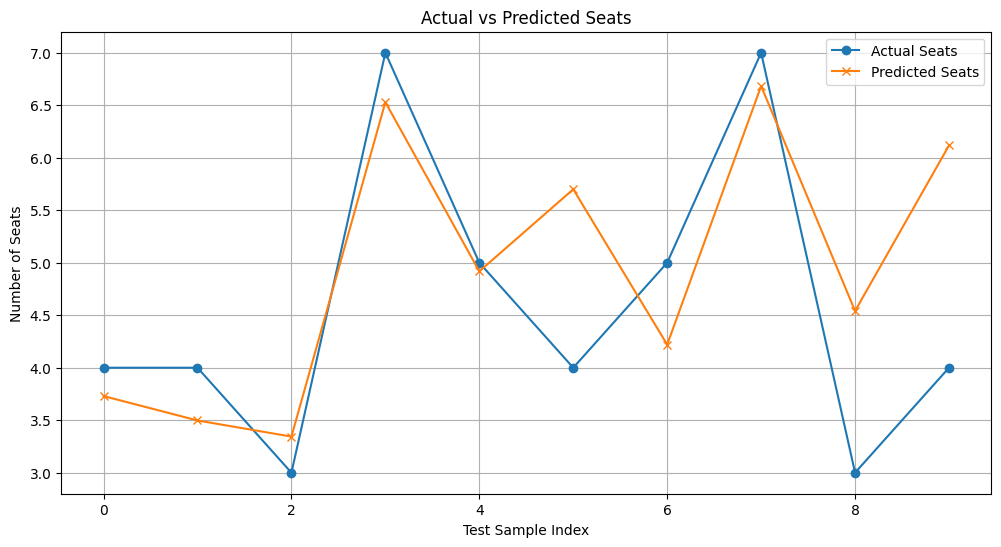

predicted_winner
NDA    44
SPA     2
Name: count, dtype: int64


In [322]:
# 3️⃣ Plot Actual vs Predicted seats
plt.figure(figsize=(12,6))
plt.plot(y_test.values, label='Actual Seats', marker='o')
plt.plot(y_pred, label='Predicted Seats', marker='x')
plt.title('Actual vs Predicted Seats')
plt.xlabel('Test Sample Index')
plt.ylabel('Number of Seats')
plt.legend()
plt.grid(True)
plt.show()
# Find the party with max votes in each row
df['predicted_winner'] = df[['nda_vote_pct','spa_vote_pct','tvk_vote_pct','ntk_vote_pct','others_pct']].idxmax(axis=1)
df['predicted_winner'] = df['predicted_winner'].str.replace('_vote_pct','').str.upper()
majority_count = df['predicted_winner'].value_counts()
print(majority_count)


Predicted seats per party:
predicted_winner
NDA    44
SPA     2
Name: count, dtype: int64


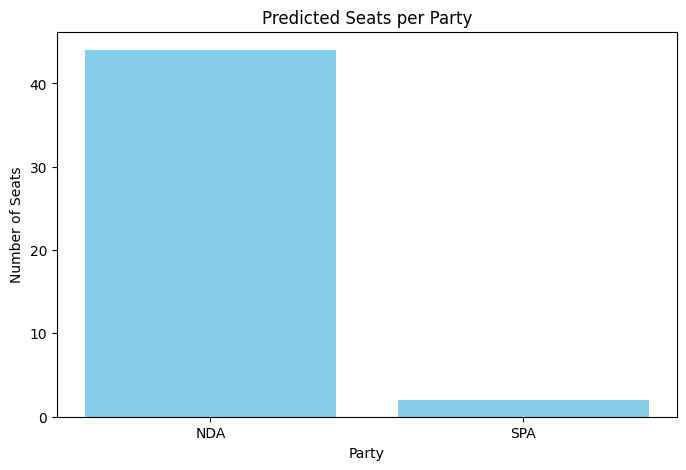

In [332]:
# Predict winner party in each constituency
vote_cols = ['nda_vote_pct','spa_vote_pct','tvk_vote_pct','ntk_vote_pct','others_pct']
df['predicted_winner'] = df[vote_cols].idxmax(axis=1)
df['predicted_winner'] = df['predicted_winner'].str.replace('_vote_pct','').str.upper()

# Count predicted seats per party
majority_count = df['predicted_winner'].value_counts()
print("Predicted seats per party:")
print(majority_count)

# Plot majority seats
plt.figure(figsize=(8,5))
plt.bar(majority_count.index, majority_count.values, color='skyblue')
plt.title("Predicted Seats per Party")
plt.xlabel("Party")
plt.ylabel("Number of Seats")
plt.show()

C:\Users\Dell\AppData\Local\Temp\ipykernel_13240\1298649480.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='predicted_winner', data=df, order=majority_count.index, palette='coolwarm')


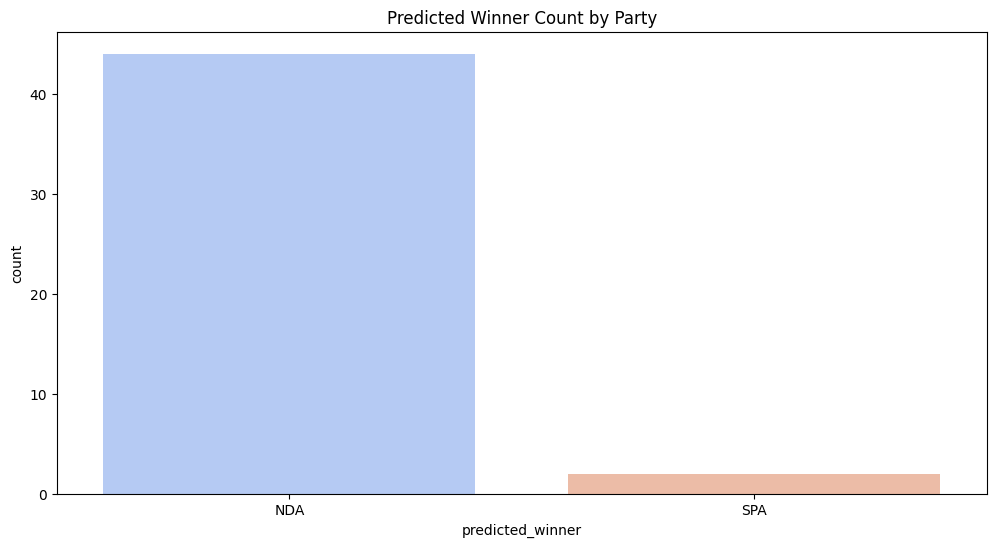

In [333]:
plt.figure(figsize=(12,6))
sns.countplot(x='predicted_winner', data=df, order=majority_count.index, palette='coolwarm')
plt.title("Predicted Winner Count by Party")
plt.show()

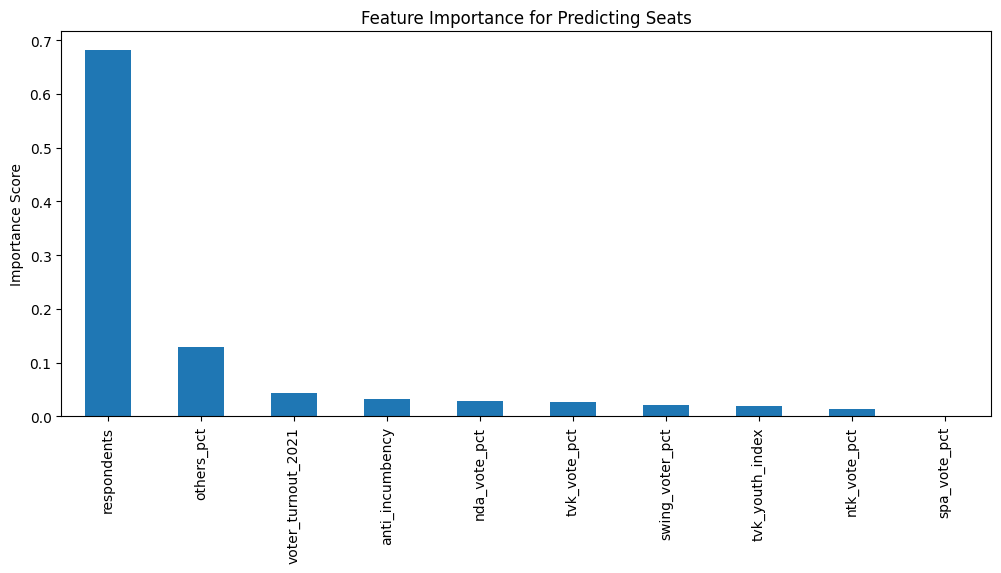

In [334]:
# 4️⃣ Optional: Feature importance chart
importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).plot(kind='bar', figsize=(12,5))
plt.title("Feature Importance for Predicting Seats")
plt.ylabel("Importance Score")
plt.show()

In [335]:
# 5️⃣ Optional: R² and Mean Absolute Error (numeric evaluation)
from sklearn.metrics import mean_absolute_error, r2_score
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print(f"R² score: {r2:.2f}")
print(f"Mean Absolute Error: {mae:.2f}")

R² score: 0.40
Mean Absolute Error: 0.81


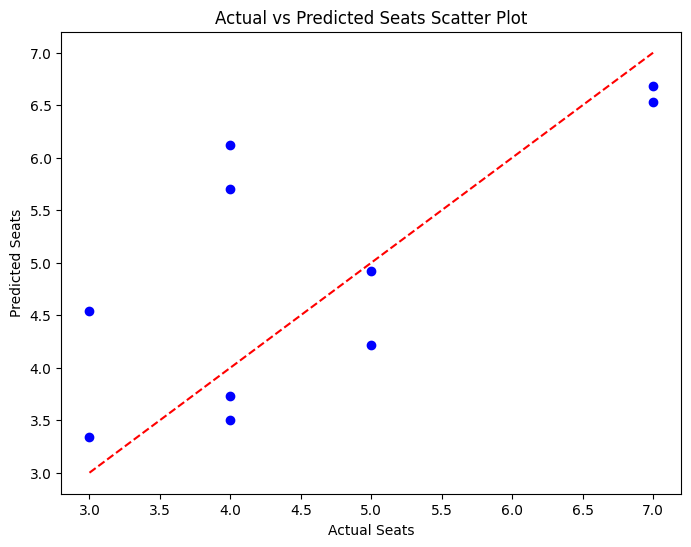

In [336]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # diagonal
plt.xlabel('Actual Seats')
plt.ylabel('Predicted Seats')
plt.title('Actual vs Predicted Seats Scatter Plot')
plt.show()